<a href="https://colab.research.google.com/github/AwaisSDev/Quantization-Collapse-Predictor/blob/main/ISEF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 494kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.58MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.41MB/s]


Training Baseline FP32 Model...
Epoch 1 complete.
Epoch 2 complete.
Epoch 3 complete.

Baseline FP32 Accuracy: 98.68%
Bit-width 32: Accuracy = 98.68%
Bit-width 8: Accuracy = 98.69%
Bit-width 4: Accuracy = 98.64%
Bit-width 2: Accuracy = 67.90%


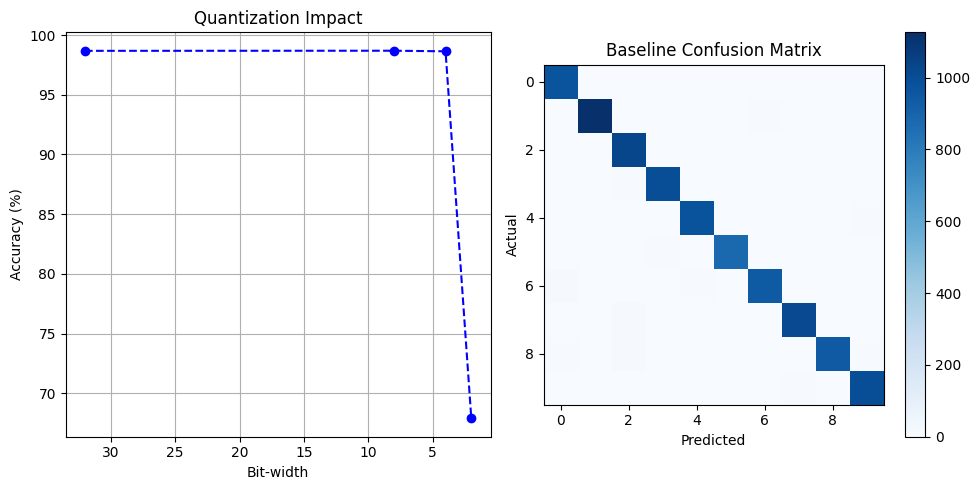

In [ ]:
# Neural Network Quantization Research Project
# Task: Evaluating Accuracy Degradation across bit-widths (32-bit to 2-bit)
# Dataset: MNIST | Framework: PyTorch

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns  # Fixed: import seaborn on its own line
from sklearn.metrics import confusion_matrix

# 1. Reproducibility & Device Configuration
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Data Preprocessing & Loading
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_set = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = DataLoader(test_set, batch_size=1000, shuffle=False)

# 3. Model Architecture (Simple CNN)
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 32 * 7 * 7)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = SimpleCNN().to(device)

# 4. Training the Baseline (FP32)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Training Baseline FP32 Model...")
model.train()
for epoch in range(3):  # Short training for research demonstration
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        output = model(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1} complete.")

# 5. Evaluation Function
def evaluate(model_to_eval):
    model_to_eval.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_to_eval(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return 100 * correct / total, all_labels, all_preds

baseline_acc, labels_list, preds_list = evaluate(model)
print(f"\nBaseline FP32 Accuracy: {baseline_acc:.2f}%")

# 6. Simulated Quantization Function
# Maps weights to a specific bit-width using Min-Max scaling
def quantize_weights(model, bits):
    if bits == 32: return model # FP32 remains unchanged

    q_model = SimpleCNN().to(device)
    q_model.load_state_dict(model.state_dict())

    with torch.no_grad():
        for param in q_model.parameters():
            # Calculate scale
            max_val = param.abs().max()
            min_val = -max_val
            q_min = -(2**(bits-1))
            q_max = (2**(bits-1)) - 1

            scale = (max_val - min_val) / (q_max - q_min)

            # Quantize and Dequantize (Simulated PTQ)
            param.copy_(torch.round(param / scale) * scale)

    return q_model

# 7. Experimentation Loop
bit_widths = [32, 8, 4, 2]
results = {}

for b in bit_widths:
    q_mod = quantize_weights(model, b)
    acc, _, _ = evaluate(q_mod)
    results[b] = acc
    print(f"Bit-width {b}: Accuracy = {acc:.2f}%")

# 8. Visualization
plt.figure(figsize=(10, 5))

# Plot 1: Bit-width vs Accuracy
plt.subplot(1, 2, 1)
plt.plot(list(results.keys()), list(results.values()), marker='o', linestyle='--', color='b')
plt.title("Quantization Impact")
plt.xlabel("Bit-width")
plt.ylabel("Accuracy (%)")
plt.gca().invert_xaxis()
plt.grid(True)

# Plot 2: Confusion Matrix (Baseline)
plt.subplot(1, 2, 2)
cm = confusion_matrix(labels_list, preds_list)
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Baseline Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

Bits 32 | MLP: 97.53% | CNN: 98.83%
Bits 8 | MLP: 97.52% | CNN: 98.85%
Bits 4 | MLP: 97.45% | CNN: 98.76%
Bits 2 | MLP: 90.47% | CNN: 86.20%


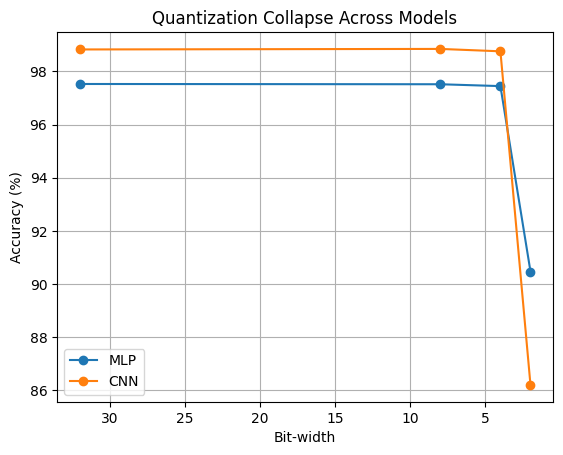

In [ ]:
# =========================
# Neural Network Quantization Universality Test
# Models: MLP + CNN
# Dataset: MNIST
# =========================

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# =========================
# DATA
# =========================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_set = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_set = torchvision.datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = DataLoader(test_set, batch_size=1000, shuffle=False)

# =========================
# MODELS
# =========================

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)


class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.fc = nn.Sequential(
            nn.Linear(32*7*7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

# =========================
# TRAIN FUNCTION
# =========================
def train(model, epochs=2):
    model.to(device)
    opt = optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.CrossEntropyLoss()

    model.train()
    for _ in range(epochs):
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            out = model(x)
            loss = loss_fn(out, y)
            loss.backward()
            opt.step()
    return model

# =========================
# EVAL FUNCTION
# =========================
def evaluate(model):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            preds = out.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return 100 * correct / total

# =========================
# SIMPLE QUANTIZATION
# =========================
def quantize(model, bits):
    if bits == 32:
        return model

    q_model = type(model)()  # same architecture
    q_model.load_state_dict(model.state_dict())
    q_model.to(device)

    with torch.no_grad():
        for p in q_model.parameters():
            max_val = p.abs().max()
            scale = max_val / (2**(bits-1))
            p.copy_(torch.round(p / scale) * scale)

    return q_model

# =========================
# EXPERIMENT RUN
# =========================
bit_widths = [32, 8, 4, 2]

results = {
    "MLP": [],
    "CNN": []
}

# Train models
mlp = train(MLP())
cnn = train(CNN())

# Test both models
for b in bit_widths:
    mlp_q = quantize(mlp, b)
    cnn_q = quantize(cnn, b)

    acc_mlp = evaluate(mlp_q)
    acc_cnn = evaluate(cnn_q)

    results["MLP"].append(acc_mlp)
    results["CNN"].append(acc_cnn)

    print(f"Bits {b} | MLP: {acc_mlp:.2f}% | CNN: {acc_cnn:.2f}%")

# =========================
# PLOT
# =========================
plt.plot(bit_widths, results["MLP"], marker='o', label="MLP")
plt.plot(bit_widths, results["CNN"], marker='o', label="CNN")

plt.gca().invert_xaxis()
plt.xlabel("Bit-width")
plt.ylabel("Accuracy (%)")
plt.title("Quantization Collapse Across Models")
plt.legend()
plt.grid()
plt.show()

Using: cuda


100%|██████████| 170M/170M [00:13<00:00, 12.7MB/s]


CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=8192, out_fea

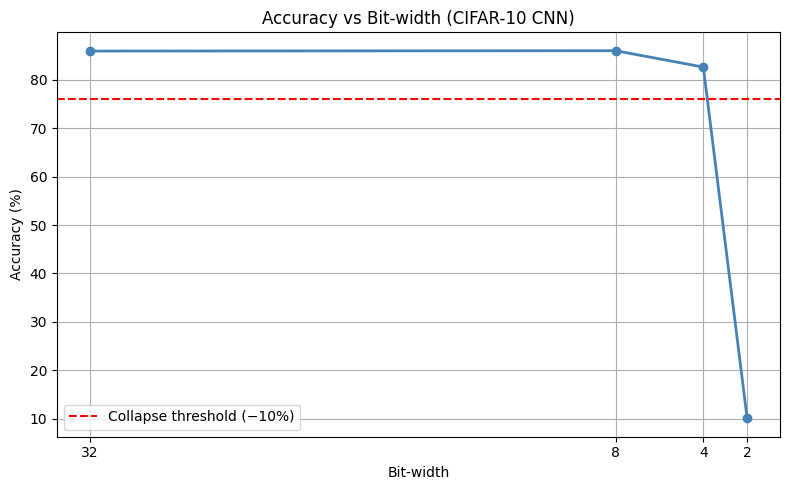

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import copy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                         download=True, transform=transform)
testset  = torchvision.datasets.CIFAR10(root='./data', train=False,
                                         download=True, transform=transform_test)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)
testloader  = torch.utils.data.DataLoader(testset,  batch_size=128, shuffle=False)

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),  nn.BatchNorm2d(32),  nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Linear(128 * 8 * 8, 512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

model = CNN().to(device)
print(model)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

def train(model, epochs=25):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        scheduler.step()
        if (epoch+1) % 5 == 0:
            print(f"Epoch {epoch+1}/25 | Loss: {total_loss/len(trainloader):.4f}")

train(model)
torch.save(model.state_dict(), "cnn_fp32.pth")
print("Model saved.")

def evaluate(model):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return 100. * correct / total

fp32_acc = evaluate(model)
print(f"FP32 Accuracy: {fp32_acc:.2f}%")

def quantize_model(model, bits):
    q_model = copy.deepcopy(model).cpu()
    q_model.eval()
    for name, module in q_model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            w = module.weight.data
            w_min, w_max = w.min(), w.max()
            levels = 2 ** bits
            scale = (w_max - w_min) / (levels - 1)
            w_q = torch.round((w - w_min) / scale) * scale + w_min
            module.weight.data = w_q
    return q_model.to(device)

results = {}
for bits in [8, 4, 2]:
    q_model = quantize_model(model, bits)
    acc = evaluate(q_model)
    drop = fp32_acc - acc
    results[bits] = {"accuracy": acc, "drop": drop}
    print(f"{bits}-bit | Accuracy: {acc:.2f}% | Drop: {drop:.2f}%")

    bit_widths = [32, 8, 4, 2]
accuracies = [fp32_acc] + [results[b]["accuracy"] for b in [8, 4, 2]]

plt.figure(figsize=(8, 5))
plt.plot(bit_widths, accuracies, marker='o', color='steelblue', linewidth=2)
plt.axhline(y=fp32_acc - 10, color='red', linestyle='--', label='Collapse threshold (−10%)')
plt.xlabel("Bit-width")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs Bit-width (CIFAR-10 CNN)")
plt.xticks([2, 4, 8, 32])
plt.legend()
plt.grid(True)
plt.gca().invert_xaxis()
plt.tight_layout()
plt.savefig("accuracy_vs_bitwidth.png", dpi=150)
plt.show()